<a href="https://colab.research.google.com/github/RanggaBraja/NLP_UTS/blob/main/NLP_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tahap 1: Instalasi Library Tambahan
Google Colab sudah memiliki sebagian besar library, namun kita perlu menginstal Sastrawi secara manual untuk stemming Bahasa Indonesia.

In [13]:
# Instal Sastrawi untuk Bahasa Indonesia
!pip install Sastrawi

Tahap 2: Pembuatan Dataset Konveksi (500 Baris)
Kita akan men-generate dummy dataset ulasan produk konveksi/pakaian terlebih dahulu agar sistem memiliki data untuk diproses.

In [14]:
import pandas as pd
import random

# Kumpulan kata seputar industri konveksi
jenis_pakaian = ['Kemeja', 'Kaos', 'Celana', 'Jaket', 'Gamis', 'Tunik', 'Rok', 'Hoodie', 'Blouse', 'Sweater']
bahan = ['katun', 'linen', 'rayon', 'polyester', 'denim', 'fleece', 'wol', 'sutra', 'spandex', 'drill']
kualitas = [
    'jahitannya sangat rapi', 'bahannya adem', 'sangat nyaman dipakai',
    'warnanya persis seperti di gambar', 'ukurannya pas di badan', 'kainnya halus',
    'menyerap keringat dengan baik', 'bahannya jatuh dan tidak kaku',
    'potongannya simetris', 'kancingnya dijahit dengan kuat'
]
konteks = [
    'cocok untuk kerja ke kantor', 'pas buat santai di rumah', 'bagus untuk acara formal',
    'nyaman dipakai sehari-hari', 'pas untuk cuaca panas', 'cocok untuk hangout bersama teman'
]
warna = ['hitam', 'putih', 'navy', 'maroon', 'abu-abu', 'coklat', 'hijau sage', 'kuning mustard']

# Fungsi generate teks acak
def generate_teks_konveksi():
    template = random.choice([1, 2, 3])
    jp, bh, ku, kt, wr = random.choice(jenis_pakaian), random.choice(bahan), random.choice(kualitas), random.choice(konteks), random.choice(warna)

    if template == 1: return f"{jp} {wr} dengan bahan {bh} ini bagus sekali. {ku.capitalize()}, dan {kt}."
    elif template == 2: return f"Saya beli {jp} berbahan {bh} di sini. {ku.capitalize()} dan menurut saya {kt}."
    else: return f"Kualitas {jp} sangat baik, kain {bh}-nya terasa premium. {ku.capitalize()}."

# Buat 500 data dan simpan ke CSV
data = [{'id_dokumen': f"DOC_{i:03d}", 'teks_dokumen': generate_teks_konveksi()} for i in range(1, 501)]
df = pd.DataFrame(data)
df.to_csv('dataset_konveksi.csv', index=False)

print("✅ Tahap 2 Selesai: File 'dataset_konveksi.csv' (500 baris) berhasil dibuat!")
display(df.head())

✅ Tahap 2 Selesai: File 'dataset_konveksi.csv' (500 baris) berhasil dibuat!


,id_dokumen,teks_dokumen
0,DOC_001,Sweater hitam dengan bahan linen ini bagus sek...
1,DOC_002,Saya beli Sweater berbahan drill di sini. Poto...
2,DOC_003,"Kualitas Hoodie sangat baik, kain linen-nya te..."
3,DOC_004,Blouse hijau sage dengan bahan fleece ini bagu...
4,DOC_005,Saya beli Sweater berbahan rayon di sini. Ukur...


tahap 3: Import Library & Text Preprocessing
Tahap ini memuat data dan membersihkannya (cleaning, tokenization, stopword removal, stemming). Proses ini mungkin memakan waktu sekitar 1-2 menit karena Sastrawi memproses kata satu per satu.

In [15]:
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import warnings
warnings.filterwarnings('ignore')

# Unduh resource tokenisasi
nltk.download('punkt')
nltk.download('punkt_tab') # Added to fix LookupError

# Inisialisasi NLP Tools
stopword_factory = StopWordRemoverFactory()
stopwords_id = stopword_factory.get_stop_words()
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def preprocess_text(text):
    # 1. Cleaning & Lowercasing
    text = re.sub(r'[^a-zA-Z\s]', '', str(text)).lower()
    # 2. Tokenization
    tokens = word_tokenize(text)
    # 3. Stopword Removal & 4. Stemming
    cleaned_tokens = [stemmer.stem(word) for word in tokens if word not in stopwords_id]
    return " ".join(cleaned_tokens), cleaned_tokens

print("Memulai proses Text Preprocessing pada 500 dokumen. Harap tunggu...")

# Terapkan ke dataset
df['processed_text'], df['tokens'] = zip(*df['teks_dokumen'].apply(preprocess_text))
processed_docs = df['processed_text'].tolist()
tokenized_docs = df['tokens'].tolist()

print("✅ Tahap 3 Selesai: Preprocessing berhasil!")
display(df[['teks_dokumen', 'processed_text']].head())

Memulai proses Text Preprocessing pada 500 dokumen. Harap tunggu...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✅ Tahap 3 Selesai: Preprocessing berhasil!


,teks_dokumen,processed_text
0,Sweater hitam dengan bahan linen ini bagus sek...,sweater hitam bahan linen bagus sekali bahan j...
1,Saya beli Sweater berbahan drill di sini. Poto...,beli sweater bahan drill sini potong simetris ...
2,"Kualitas Hoodie sangat baik, kain linen-nya te...",kualitas hoodie sangat baik kain linen asa pre...
3,Blouse hijau sage dengan bahan fleece ini bagu...,blouse hijau sage bahan fleece bagus sekali po...
4,Saya beli Sweater berbahan rayon di sini. Ukur...,beli sweater bahan rayon sini ukur pas badan p...


Tahap 4: Visualisasi 1 (Word Cloud)
Melihat kata-kata yang paling dominan muncul dalam ulasan produk konveksi.

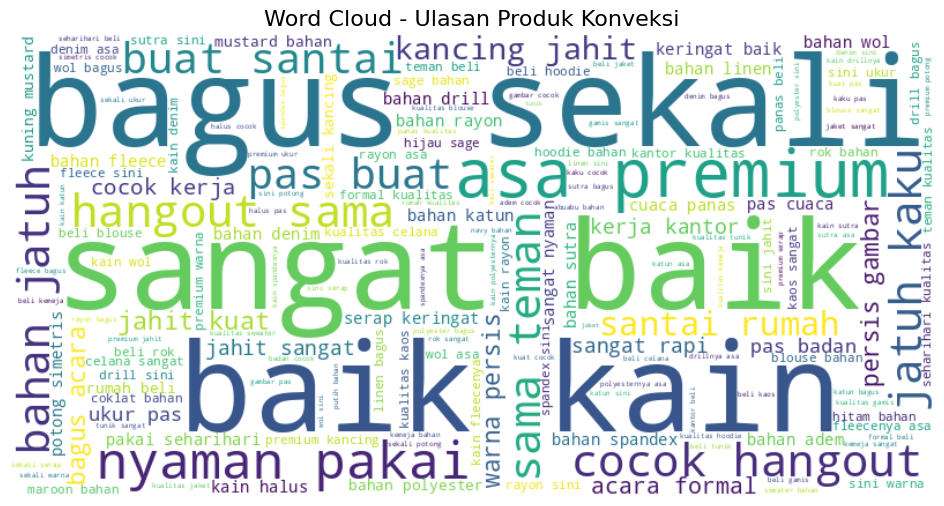

In [16]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

all_text = " ".join(processed_docs)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', stopwords=set(stopwords_id)).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Ulasan Produk Konveksi', fontsize=16)
plt.show()

Tahap 5: Representasi Teks (TF-IDF & Word2Vec)
Mengubah teks yang sudah bersih menjadi angka (vektor) agar bisa dihitung oleh komputer.

In [17]:
# Install gensim library
!pip install gensim

In [18]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

# --- 1. Model TF-IDF ---
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)

# --- 2. Model Word2Vec ---
w2v_model = Word2Vec(sentences=tokenized_docs, vector_size=100, window=5, min_count=1, workers=4)

# Fungsi mengubah dokumen menjadi vektor Word2Vec (rata-rata vektor kata)
def get_document_vector(tokens, model, vector_size):
    vec = np.zeros(vector_size)
    count = 0
    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    if count != 0:
        vec /= count
    return vec

w2v_matrix = np.array([get_document_vector(tokens, w2v_model, 100) for tokens in tokenized_docs])

print("✅ Tahap 5 Selesai: Vektor TF-IDF dan Word2Vec berhasil dibentuk!")

✅ Tahap 5 Selesai: Vektor TF-IDF dan Word2Vec berhasil dibentuk!


Tahap 6: Sistem Pencarian (Information Retrieval)
Ini adalah mesin pencari utamanya. Anda bisa mengubah variabel query_test untuk mencari barang spesifik di kumpulan dokumen tadi.

In [19]:
def search_system(query, top_n=3):
    """
    Performs information retrieval using TF-IDF and Word2Vec models.

    Args:
        query (str): The search query.
        top_n (int): The number of top results to return for each method.
    """
    print(f"MENCARI QUERY: '{query}'\n" + "="*50)

    # Preprocess Query
    query_processed, query_tokens = preprocess_text(query)

    # TF-IDF Search
    query_vec_tfidf = tfidf_vectorizer.transform([query_processed])
    sim_tfidf = cosine_similarity(query_vec_tfidf, tfidf_matrix).flatten()
    top_tfidf = sim_tfidf.argsort()[-top_n:][::-1]

    print("🎯 HASIL METODE TF-IDF (Pencarian Kata Eksak):")
    for idx in top_tfidf:
        print(f"Skor: {sim_tfidf[idx]:.4f} | Dok: {df['teks_dokumen'].iloc[idx]}")

    # Word2Vec Search
    # Ensure query_vec_w2v is handled gracefully if query_tokens is empty or contains no known words
    query_vec_w2v = get_document_vector(query_tokens, w2v_model, 100).reshape(1, -1)
    sim_w2v = cosine_similarity(query_vec_w2v, w2v_matrix).flatten()
    top_w2v = sim_w2v.argsort()[-top_n:][::-1]

    print("\n🧠 HASIL METODE WORD2VEC (Pencarian Makna/Konteks):")
    for idx in top_w2v:
        print(f"Skor: {sim_w2v[idx]:.4f} | Dok: {df['teks_dokumen'].iloc[idx]}")

# --- TES MESIN PENCARI ---
# Ubah kalimat di bawah ini untuk menguji pencarian Anda sendiri!
query_test = "Kemeja katun untuk dipakai kerja"
search_system(query_test, top_n=3)

MENCARI QUERY: 'Kemeja katun untuk dipakai kerja'
🎯 HASIL METODE TF-IDF (Pencarian Kata Eksak):
Skor: 0.5135 | Dok: Kemeja coklat dengan bahan katun ini bagus sekali. Kancingnya dijahit dengan kuat, dan cocok untuk kerja ke kantor.
Skor: 0.5126 | Dok: Saya beli Kemeja berbahan sutra di sini. Sangat nyaman dipakai dan menurut saya cocok untuk kerja ke kantor.
Skor: 0.4623 | Dok: Kemeja navy dengan bahan rayon ini bagus sekali. Sangat nyaman dipakai, dan cocok untuk kerja ke kantor.

🧠 HASIL METODE WORD2VEC (Pencarian Makna/Konteks):
Skor: 0.9998 | Dok: Saya beli Kemeja berbahan sutra di sini. Sangat nyaman dipakai dan menurut saya cocok untuk kerja ke kantor.
Skor: 0.9998 | Dok: Kemeja navy dengan bahan rayon ini bagus sekali. Sangat nyaman dipakai, dan cocok untuk kerja ke kantor.
Skor: 0.9998 | Dok: Kemeja coklat dengan bahan katun ini bagus sekali. Kancingnya dijahit dengan kuat, dan cocok untuk kerja ke kantor.


Tahap 7: Visualisasi 2 (PCA Word Embeddings)
Mereduksi dimensi vektor dari 100D menjadi 2D untuk melihat peta persebaran kata. Kata-kata yang sering muncul bersamaan akan berdekatan di dalam plot grafik ini.

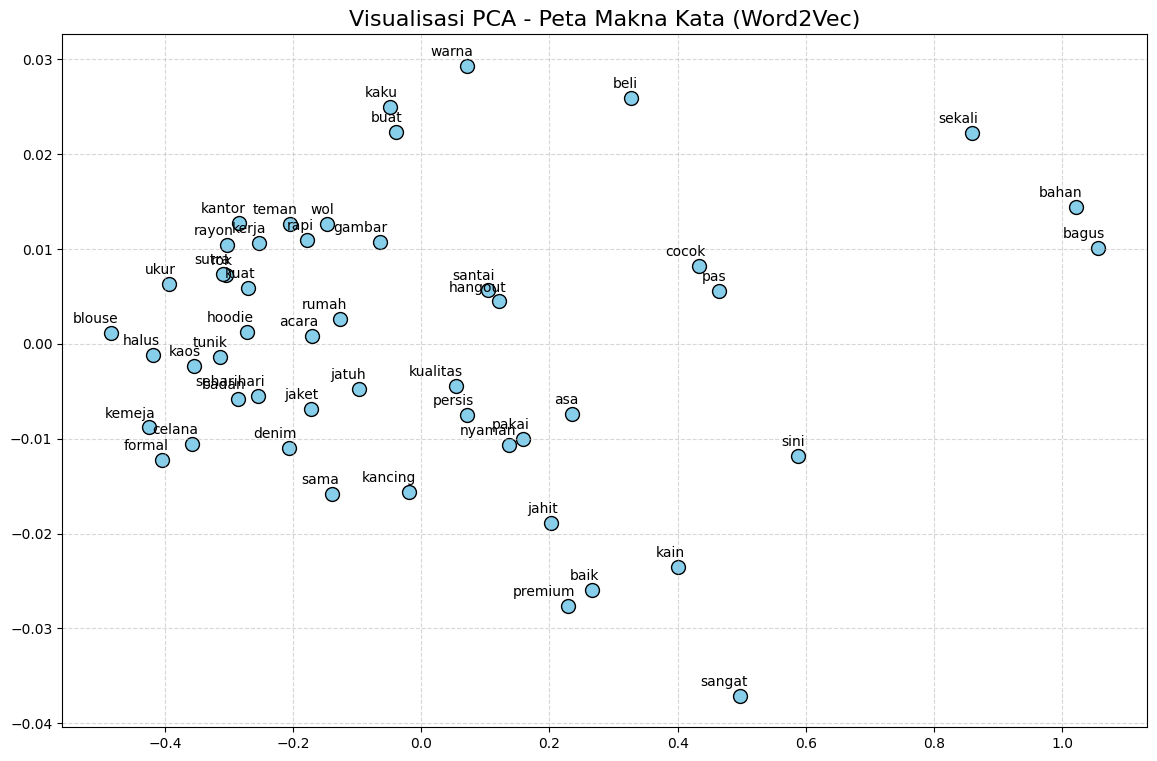

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Ambil 50 kata yang paling sering muncul
words = list(w2v_model.wv.index_to_key)[:50]
vectors = np.array([w2v_model.wv[word] for word in words])

# Reduksi dimensi dengan PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plotting
plt.figure(figsize=(14, 9))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='skyblue', s=100)

for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 5),
                 textcoords='offset points', ha='right', va='bottom', fontsize=10)

plt.title('Visualisasi PCA - Peta Makna Kata (Word2Vec)', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()